In [1]:
!git clone https://huggingface.co/datasets/CSALT/deepfake_detection_dataset_urdu

Cloning into 'deepfake_detection_dataset_urdu'...
remote: Enumerating objects: 6796, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 6796 (delta 0), reused 0 (delta 0), pack-reused 6793 (from 1)
Receiving objects: 100% (6796/6796), 957.64 KiB | 4.15 MiB/s, done.
Resolving deltas: 100% (2/2), done.
Updating files: 100% (6796/6796), done.
Filtering content: 100% (6794/6794), 1.82 GiB | 8.65 MiB/s, done.


In [2]:
# ========================
# TRAINING PIPELINE (EfficientNet-B0 backbone)
# ========================
import os, glob, random, math, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torchaudio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from collections import Counter

# reproducibility
def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================
# STEP 1: Files & Splits
# ========================
base_path = "/content/deepfake_detection_dataset_urdu"

real_files = glob.glob(os.path.join(base_path, "Bonafide", "**", "*.wav"), recursive=True)
fake_files = glob.glob(os.path.join(base_path, "Spoofed_TTS", "**", "*.wav"), recursive=True)
fake_files += glob.glob(os.path.join(base_path, "Spoofed_Tacotron", "**", "*.wav"), recursive=True)

print(f"Total Real: {len(real_files)}, Total Fake: {len(fake_files)}")
assert len(real_files) + len(fake_files) > 0, "No audio files found. Check paths."

all_files = [(f, 0) for f in real_files] + [(f, 1) for f in fake_files]
labels_all = [lbl for _, lbl in all_files]

train_files, test_files = train_test_split(all_files, test_size=0.2, stratify=labels_all, random_state=42)
labels_train = [lbl for _, lbl in train_files]
train_files, val_files = train_test_split(train_files, test_size=0.2, stratify=labels_train, random_state=42)

print(f"Train: {len(train_files)}, Val: {len(val_files)}, Test: {len(test_files)}")

# ========================
# STEP 2: Dataset
# ========================
class AudioDataset(Dataset):
    def __init__(self, file_list, is_train=False, target_len=1024):
        self.file_list = file_list
        self.is_train = is_train
        self.target_len = target_len
        self.sr = 16000

        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sr, n_mels=128, n_fft=1024,
            hop_length=256, f_min=20, f_max=7600, power=2.0
        )
        self.amp_to_db = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)

        # SpecAugment
        self.freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=12)
        self.time_mask_param = max(8, int(0.1 * self.target_len))
        self.time_mask = torchaudio.transforms.TimeMasking(time_mask_param=self.time_mask_param)

        # image transforms
        self.img_tx = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def _fix_length(self, x: torch.Tensor, T: int):
        curT = x.shape[-1]
        if curT == T: return x
        if curT < T:
            pad = T - curT
            return torch.nn.functional.pad(x, (0, pad))
        if self.is_train:
            start = np.random.randint(0, curT - T + 1)
        else:
            start = (curT - T) // 2
        return x[..., start:start+T]

    def __len__(self): return len(self.file_list)

    def __getitem__(self, idx):
        filepath, label = self.file_list[idx]
        wav, sr = torchaudio.load(filepath)
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        if wav.dim() == 2 and wav.size(0) > 1:
            wav = wav.mean(dim=0, keepdim=True)

        mel = self.mel(wav)
        mel = self.amp_to_db(mel)
        mel = torch.clamp(mel, min=-80.0, max=0.0)
        mel = (mel + 80.0) / 80.0
        mel = self._fix_length(mel, self.target_len)

        if self.is_train:
            mel = self.freq_mask(mel)
            mel = self.time_mask(mel)

        mel3 = mel.repeat(3, 1, 1)
        mel3 = self.img_tx(mel3)
        return mel3, torch.tensor(label, dtype=torch.long)

# ========================
# STEP 3: DataLoaders
# ========================
batch_size = 16
num_workers = 4 if torch.cuda.is_available() else 2
pin_memory = torch.cuda.is_available()

train_ds = AudioDataset(train_files, is_train=True, target_len=1024)
val_ds   = AudioDataset(val_files,   is_train=False, target_len=1024)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)

# ========================
# STEP 4: Model (EfficientNet-B0)
# ========================
class EfficientNetB0Classifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()
        if pretrained:
            try:
                self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
            except Exception:
                self.backbone = models.efficientnet_b0(pretrained=True)
        else:
            self.backbone = models.efficientnet_b0(weights=None)

        in_feats = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_feats, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = EfficientNetB0Classifier(num_classes=2, pretrained=True).to(device)

# ========================
# STEP 5: Loss, Optimizer, Scheduler
# ========================
train_labels = [lbl for _, lbl in train_files]
class_counts = np.bincount(train_labels)
class_weights = torch.tensor(1.0 / (class_counts + 1e-6), dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * 2.0
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=2, T_mult=2, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

best_val_acc = 0.0
num_epochs = 12
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# ========================
# STEP 6: Training Loop
# ========================
for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [train]", leave=False)
    for x, y in pbar:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_acc = correct / total
    train_loss /= total

    # ---- Validation ----
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad(), torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
        for x, y in val_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    val_loss /= total
    scheduler.step(epoch + 1)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "urdu_best_model.pth")
        print("✅ Saved best model with Val Acc:", f"{best_val_acc:.4f}")

print("Training complete. Best Val Acc:", best_val_acc)

Using device: cuda
Total Real: 3398, Total Fake: 3396
Train: 4348, Val: 1087, Test: 1359
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 122MB/s]


Epoch 01 | Train Loss: 0.1210, Train Acc: 0.9556 | Val Loss: 0.0072, Val Acc: 0.9982
✅ Saved best model with Val Acc: 0.9982


Epoch 02 | Train Loss: 0.0272, Train Acc: 0.9926 | Val Loss: 0.0027, Val Acc: 1.0000
✅ Saved best model with Val Acc: 1.0000


Epoch 03 | Train Loss: 0.0345, Train Acc: 0.9890 | Val Loss: 0.0105, Val Acc: 0.9945


...

Epoch 08 | Train Loss: 0.0122, Train Acc: 0.9970 | Val Loss: 0.0004, Val Acc: 1.0000


Epoch 09 | Train Loss: 0.0109, Train Acc: 0.9959 | Val Loss: 0.0002, Val Acc: 1.0000


Epoch 10 | Train Loss: 0.0031, Train Acc: 0.9993 | Val Loss: 0.0002, Val Acc: 1.0000


Epoch 11 | Train Loss: 0.0025, Train Acc: 0.9995 | Val Loss: 0.0002, Val Acc: 1.0000


Epoch 12 | Train Loss: 0.0036, Train Acc: 0.9984 | Val Loss: 0.0004, Val Acc: 1.0000
Training complete. Best Val Acc: 1.0


Using device: cuda
✅ Loaded model from urdu_best_model.pth


Testing: 100%|██████████| 85/85 [00:23<00:00,  3.55it/s]



Test Loss: 0.0025 | Test Accuracy: 0.9993

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       680
           1       1.00      1.00      1.00       679

    accuracy                           1.00      1359
   macro avg       1.00      1.00      1.00      1359
weighted avg       1.00      1.00      1.00      1359



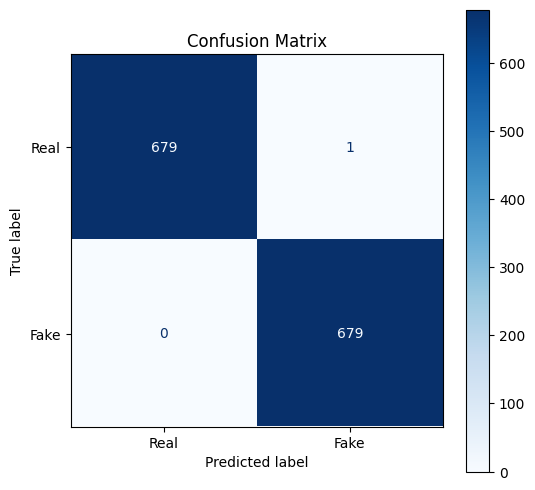

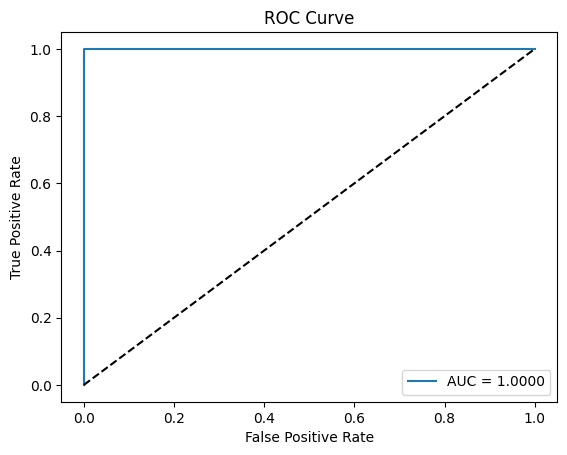

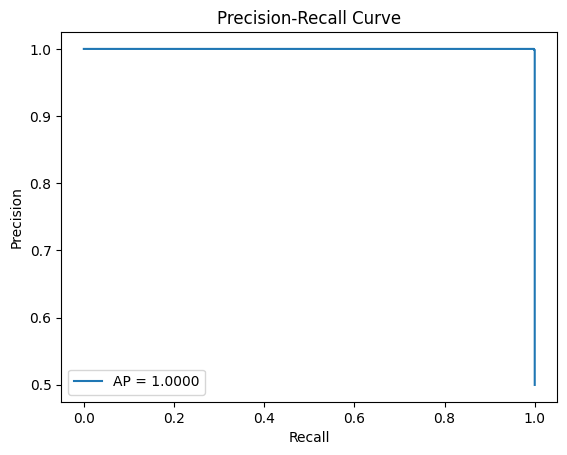

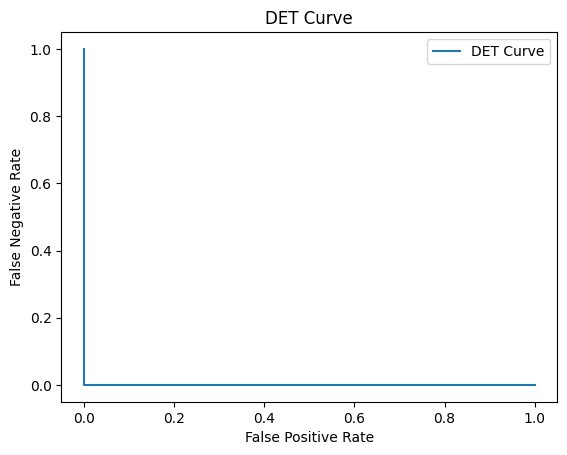

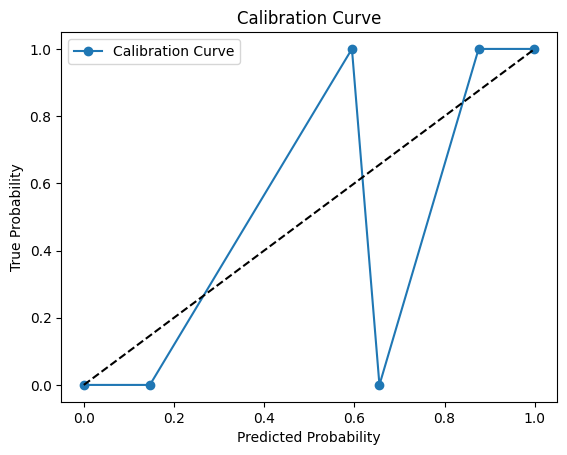

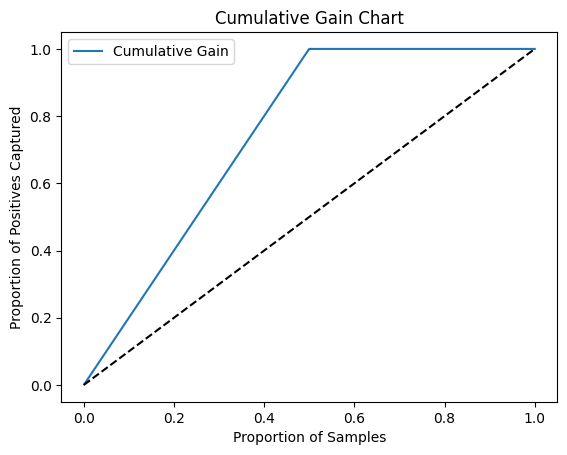


=========== Final Metrics ===========
Accuracy: 0.9993
AUC: 1.0000
EER: 0.15%
min t-DCF: 0.0007
Average Precision (AP): 1.0000
Brier Score: 0.0005
KS Statistic: 0.9985 (p=0.0000)


In [3]:
# ========================
# TESTING PIPELINE (EfficientNet-B0 + Extended Evaluation)
# ========================
import os, glob, warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, brier_score_loss,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from tqdm import tqdm
from scipy.stats import ks_2samp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ========================
# STEP 1: Dataset Class
# ========================
class AudioDataset(Dataset):
    def __init__(self, file_list, target_len=1024):
        self.file_list = file_list
        self.target_len = target_len
        self.sr = 16000

        self.mel = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sr, n_mels=128, n_fft=1024,
            hop_length=256, f_min=20, f_max=7600, power=2.0
        )
        self.amp_to_db = torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)

        self.img_tx = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    def _fix_length(self, x: torch.Tensor, T: int):
        curT = x.shape[-1]
        if curT == T: return x
        if curT < T:
            pad = T - curT
            return torch.nn.functional.pad(x, (0, pad))
        start = (curT - T) // 2
        return x[..., start:start+T]

    def __len__(self): return len(self.file_list)

    def __getitem__(self, idx):
        filepath, label = self.file_list[idx]
        wav, sr = torchaudio.load(filepath)
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        if wav.dim() == 2 and wav.size(0) > 1:
            wav = wav.mean(dim=0, keepdim=True)

        mel = self.mel(wav)
        mel = self.amp_to_db(mel)
        mel = torch.clamp(mel, min=-80.0, max=0.0)
        mel = (mel + 80.0) / 80.0
        mel = self._fix_length(mel, self.target_len)

        mel3 = mel.repeat(3, 1, 1)
        mel3 = self.img_tx(mel3)
        return mel3, torch.tensor(label, dtype=torch.long)

# ========================
# STEP 2: Model
# ========================
class EfficientNetB0Classifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        in_feats = self.backbone.classifier[1].in_features
        self.backbone.classifier[1] = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_feats, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# ========================
# STEP 3: Load Model
# ========================
model = EfficientNetB0Classifier(num_classes=2).to(device)
model.load_state_dict(torch.load("urdu_best_model.pth", map_location=device))
model.eval()
print("✅ Loaded model from urdu_best_model.pth")

# ========================
# STEP 4: Load Test Data
# ========================
base_path = "/content/deepfake_detection_dataset_urdu"
real_files = glob.glob(os.path.join(base_path, "Bonafide", "**", "*.wav"), recursive=True)
fake_files = glob.glob(os.path.join(base_path, "Spoofed_TTS", "**", "*.wav"), recursive=True)
fake_files += glob.glob(os.path.join(base_path, "Spoofed_Tacotron", "**", "*.wav"), recursive=True)

all_files = [(f, 0) for f in real_files] + [(f, 1) for f in fake_files]

from sklearn.model_selection import train_test_split
labels_all = [lbl for _, lbl in all_files]
_, test_files = train_test_split(all_files, test_size=0.2,
                                 stratify=labels_all, random_state=42)

test_ds = AudioDataset(test_files, target_len=1024)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False,
                         num_workers=2, pin_memory=torch.cuda.is_available())

# ========================
# STEP 5: Helper Metrics
# ========================
def compute_eer(fpr, tpr):
    fnr = 1 - tpr
    abs_diffs = np.abs(fpr - fnr)
    idx = np.argmin(abs_diffs)
    return ((fpr[idx] + fnr[idx]) / 2) * 100

def compute_min_tDCF(fpr, fnr, Cmiss=1, Cfa=1, Ptar=0.5):
    tDCF = Cmiss * Ptar * fnr + Cfa * (1 - Ptar) * fpr
    return np.min(tDCF)

# ========================
# STEP 6: Evaluation
# ========================
criterion = nn.CrossEntropyLoss()
test_loss, correct, total = 0.0, 0, 0
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad(), torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
    for x, y in tqdm(test_loader, desc="Testing"):
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        test_loss += loss.item() * x.size(0)

        probs = torch.softmax(logits, dim=1)[:, 1]  # probability for "Fake"
        preds = logits.argmax(1)

        correct += (preds == y).sum().item()
        total += y.size(0)
        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_loss /= total
test_acc = correct / total

print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")
print("\nClassification Report:\n", classification_report(all_labels, all_preds))

# ========================
# STEP 7: Confusion Matrix
# ========================
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
plt.title("Confusion Matrix")
plt.show()

# ========================
# STEP 8: Advanced Metrics
# ========================
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_scores = np.array(all_probs)

# ROC / AUC / EER / min t-DCF
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc_score = roc_auc_score(y_true, y_scores)
eer = compute_eer(fpr, tpr)
min_tDCF = compute_min_tDCF(fpr, 1 - tpr)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_scores)
ap = average_precision_score(y_true, y_scores)
plt.plot(recall, precision, label=f"AP = {ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# DET Curve
fnr = 1 - tpr
plt.plot(fpr, fnr, label="DET Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("False Negative Rate")
plt.title("DET Curve")
plt.legend()
plt.show()

# Calibration Curve + Brier Score
prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label="Calibration Curve")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()
brier = brier_score_loss(y_true, y_scores)

# KS Statistic
real_scores = y_scores[y_true == 0]
fake_scores = y_scores[y_true == 1]
ks_stat, ks_p = ks_2samp(real_scores, fake_scores)

# Lift / Cumulative Gain
sorted_indices = np.argsort(-y_scores)
y_sorted = y_true[sorted_indices]
gains = np.cumsum(y_sorted) / np.sum(y_sorted)
perc = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
plt.plot(perc, gains, label="Cumulative Gain")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Proportion of Samples")
plt.ylabel("Proportion of Positives Captured")
plt.title("Cumulative Gain Chart")
plt.legend()
plt.show()

# ========================
# STEP 9: Final Metrics Summary
# ========================
print("\n=========== Final Metrics ===========")
print(f"Accuracy: {test_acc:.4f}")
print(f"AUC: {auc_score:.4f}")
print(f"EER: {eer:.2f}%")
print(f"min t-DCF: {min_tDCF:.4f}")
print(f"Average Precision (AP): {ap:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"KS Statistic: {ks_stat:.4f} (p={ks_p:.4f})")